In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import s3fs
import xarray as xr
import os

# Xarray dark mode hack
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

In [2]:
fs = s3fs.S3FileSystem(
    key=os.environ["AWS_ACCESS_KEY_ID"],
    secret=os.environ["AWS_SECRET_ACCESS_KEY"],
    client_kwargs={"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    config_kwargs={
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
                }
)

storage_options = {
    "client_kwargs": {"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    "config_kwargs": {
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
    },
}

In [3]:
ds = xr.open_dataset('s3://gaia/cjense/data/airtemp/KPC_U_mixed.zarr',                      
                     storage_options=storage_options,
                     zarr_format=3,
                     consolidated=False,
                     mode="r",
                     engine="zarr")

ds

<xarray.Dataset> Size: 393MB
Dimensions:                (time: 806064)
Coordinates:
  * time                   (time) datetime64[ns] 6MB 2008-07-17T18:20:00 ... ...
Data variables: (12/60)
    dlr                    (time) float64 6MB ...
    batt_v                 (time) float64 6MB ...
    albedo                 (time) float64 6MB ...
    gps_alt                (time) float64 6MB ...
    gps_geoid              (time) float64 6MB ...
    fan_dc_u               (time) float64 6MB ...
    ...                     ...
    z_boom_q_u             (time) float64 6MB ...
    z_pt_cor               (time) float64 6MB ...
    z_boom_u               (time) float64 6MB ...
    z_stake                (time) float64 6MB ...
    z_stake_q              (time) float64 6MB ...
    z_stake_cor            (time) float64 6MB ...
Attributes: (12/80)
    level:                           L2
    detected_file_type:              toa5
    filename:                        KPC_U_2026_raw.txt
    format:                          merged RAW and TX
    latitude:                        79.83460454373761
    longitude:                       -25.16558150256901
    ...                              ...
    publisher_url:                   https://promice.dk
    references:                      How, P.; Lund, M.C.; Ahlstrøm, A.P.; And...
    references_bib:                  @article{PROMICE_2022
    standard_name_vocabulary:        CF Standard Name Table (v77; 19 January ...
    summary:                         The Programme for Monitoring of the Gree...
    source:                          {"pypromice": "1.12.0", "l0_config_file"...

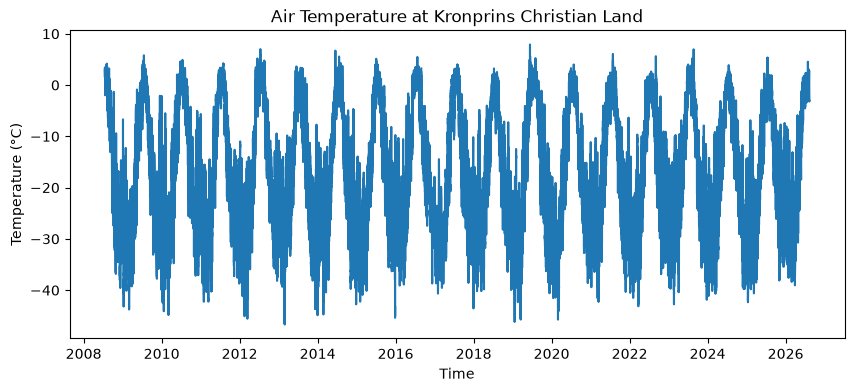

In [4]:
fig, ax = plt.subplots(figsize=(10,4))
plt.plot(ds.time, ds.t_u)

plt.xlabel('Time')
plt.ylabel("Temperature (°C)")
plt.title('Air Temperature at Kronprins Christian Land')

plt.savefig('figures/airtemp.png', dpi=300)

plt.show()